# Reproducibility Vignette for SyNBEATS

This vignette demonstrates our implementation of SyNBEATS for the simulated data. Below we first load the required packages and the necessary dependencies. The version and environment controls are available in the following link:

SyNBEATS repository: [`https://github.com/Crabtain959/SyNBEATS`](https://github.com/Crabtain959/SyNBEATS).

In [1]:
import numpy as np
import pandas as pd
import os, time, warnings
from SyNBEATS import SyNBEATS
from darts import TimeSeries
from darts.metrics import mae
from joblib import Parallel, delayed
from tqdm import tqdm

/home/nd329/venvs/synbeats/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


User needs to maintain the home directory accordingly. The simulated data file `DGP0_Y_N64_T32_iter1.csv` contains the outcome matrix for $N = 64$, $T = 32$ and for the first replicate. The post treatment data has length $T/4$ and the pretreatment panel (before and including time $T$) is fully observed.

In [ ]:
# Change the directory according to the home directory where you keep the folder
os.chdir(os.path.expanduser("~/causal_forecast/data_files/DGP4/Y_files"))
filename = "DGP4_Y_N64_32_iter1.csv"
Y = pd.read_csv(filename)
TT = int(filename.split("T")[1].split("_")[0])

# Reshape the panel
Y_train = Y.iloc[:, :TT + TT//4]
Y_long = Y_train.stack().reset_index()
Y_long.columns = ["id", "time", "Y_obs"]
Y_long["time"] = Y_long["time"].str.extract("V(\d+)").astype(int) - 1
Y_long.head

<bound method NDFrame.head of       id  time     Y_obs
0      0     0 -0.490534
1      0     1 -0.205141
2      0     2 -0.398444
3      0     3 -0.377642
4      0     4 -0.848275
...   ..   ...       ...
2555  31    75  0.263348
2556  31    76  0.151429
2557  31    77  0.036839
2558  31    78  0.153376
2559  31    79  0.061850

[2560 rows x 3 columns]>

Now we run the model of SyNBEATS for a user 1. Since we don't have access to GPU we use CPU to train the model. 

In [8]:
model = SyNBEATS(Y_long, treat_ids = [1], target_time = TT, date_format = None)
model.train(use_gpu = 0, verbose=False)
predictions = model.predict(verbose=False)

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


Next we use the trained model to predict the 3 post treatment period for treated user. The plots capture the post treatment outcome trajectories and its departure from the observed outcome variables.

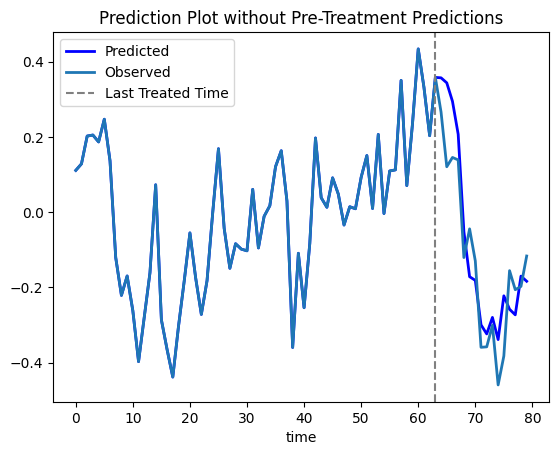

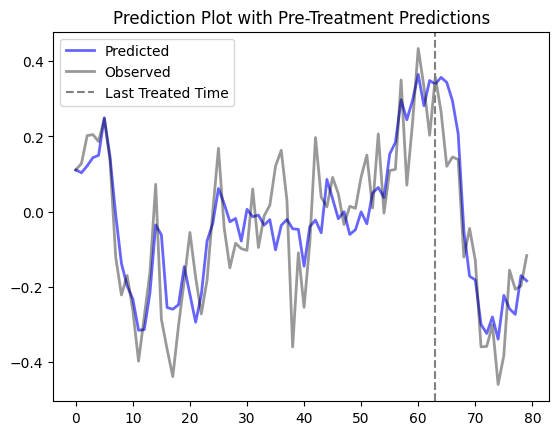

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


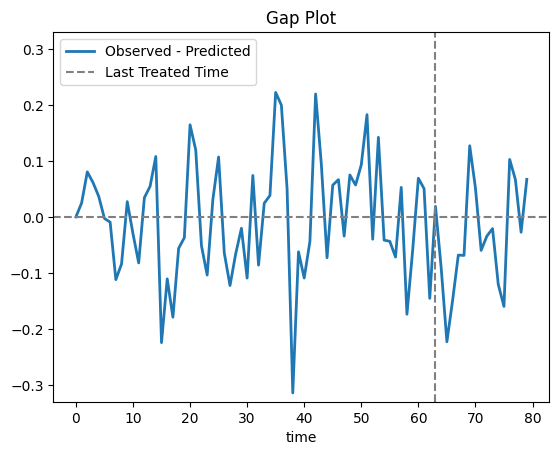

array([0.35691617, 0.34355324, 0.29440014])

In [9]:
model.plot_predictions(predictions)
model.plot_predictions(predictions, predict_pretreatment = True)  
# by setting predict_pretreatment=True, you can visualize the pretreatment predictions
model.plot_gap()
predictions.values().flatten()[:3]

Now we generalize the operation for any fixed $N$ and $T$ for 30 trials. Since the code performs substantially slower than the benchmarks FOCUS and mSSA, we run ot fixing $N$ and $T$, and changing their values manually for keeping track of the outputs. The prediction function is implemented over 30 trials with 4 cores in parallel.

In [ ]:
### User needs to change accordingly following the location of Y_files
os.chdir(os.path.expanduser("~/causal_forecast/data_files/DGP4/Y_files"))

def process_file(N, TT, n):
    file_name = f"DGP4_Y_N{N}_T{TT}_iter{n}.csv"
    Y = pd.read_csv(file_name)
    Y.index.name = 'user'
    Y.columns.name = 'time'

    # Reshape to long
    Y_train = Y.iloc[:, :TT + TT//4]
    Y_long = Y_train.stack().reset_index()
    Y_long.columns = ["id", "time", "Y_obs"]
    Y_long["time"] = Y_long["time"].str.extract(r"V(\d+)").astype(int) - 1

    results = []
    t0 = time.perf_counter()   # <<< start timer
    for i in range(32):
        model = SyNBEATS(Y_long, treat_ids=[i], target_time=TT)
        model.train(use_gpu=0, verbose=False)
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", UserWarning)
            predictions = model.predict(verbose=False)

        preds_first3 = np.array(list(predictions.values()))[:3].flatten()
        results.append(preds_first3)

        print(f"Finished user {i} for file {n}", flush=True)
    
    runtime_sec = time.perf_counter() - t0   # <<< end timer
    # Convert to DataFrame (32 x 3)
    df_out = pd.DataFrame(results, columns=["h1", "h2", "h3"])
    df_out.index.name = "id"

    out_dir = os.path.join("..", "synout_files", f"N{N}_T{TT}")
    os.makedirs(out_dir, exist_ok=True)

    out_file = os.path.join(out_dir, f"synout_DGP4_Y_N{N}_T{TT}_iter{n}.csv")
    df_out.to_csv(out_file, index=True)

    print(f"Finished n={n}, saved: {out_file} (runtime: {runtime_sec:.2f}s)", flush=True)

    # Return runtime to write in CSV
    return {"iter": n, "runtime_sec": runtime_sec}


Below we produce the outputs of the first 32 users and $T = 32$ time points. The forecasted panels across the 30 trials are saved as CSV files and later imported in R for the benchmark analysis. 

In [ ]:
N = 64
TT = 256
### range of TT : 32, 64, 128, 256, 512.

out_dir = os.path.join("..", "synout_files", f"N{N}_T{TT}")
os.makedirs(out_dir, exist_ok=True)

# run for n = 1,...,30
runtime_rows = Parallel(n_jobs=30)(
    delayed(process_file)(N, TT, n) for n in tqdm(range(1, 31))
)

# Save runtimes (single column, one row per iteration)
df_runtime = pd.DataFrame(runtime_rows).sort_values("iter").reset_index(drop=True)
runtime_file = os.path.join(out_dir, f"synruntime_DGP4_Y_N{N}_T{TT}.csv")
df_runtime[["runtime_sec"]].to_csv(runtime_file, index=False)

print(f"Saved runtime CSV: {runtime_file}", flush=True)

100%|██████████| 30/30 [00:00<00:00, 76.26it/s]
/home/nd329/venvs/synbeats/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/nd329/venvs/synbeats/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
/home/nd329/venvs/synbeats/lib/python3.10/site-packages/lightning_fabric/__init__.py:41: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81

Finished user 0 for file 5


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


Finished user 0 for file 9
Finished user 0 for file 17


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


...

`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


Finished user 4 for file 11


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.


Finished user 5 for file 5


`predict()` was called with `n > output_chunk_length`: using auto-regression to forecast the values after `output_chunk_length` points. The model will access `(n - output_chunk_length)` future values of your `past_covariates` (relative to the first predicted time step). To hide this warning, set `show_warnings=False`.
